# Stimulus features QC (Lexical Delay)

Visual verification of token-level **acoustic** (mel log-mean) and **phonological** (position×phone) features cached in `src/semantic/features/stimulus_features.h5`.

Regenerate cache:

```bash
python src/semantic/build_stimulus_features.py
# or: sbatch scripts/slurm/build_stimulus_features.sh
```

Review this notebook before controlled semantic encoding.

In [1]:
from __future__ import annotations

from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rootutils
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from sklearn.manifold import MDS

root = rootutils.setup_root(
    search_from=Path.cwd(),
    indicator=".project-root",
    pythonpath=True,
    cwd=True,
)

from src.semantic.load_stimulus_features import load_stimulus_features

FEATURES_H5 = root / "src/semantic/features/stimulus_features.h5"
EXAMPLE_TOKENS = ["baron", "seven", "modem", "civic", "banic", "cazel"]

SR_TARGET = 16_000
N_MELS = 16
FMIN = 50.0
FMAX = 8_000.0
HOP_LENGTH = 160
N_FFT = 512
LOG_EPS = 1e-10

feat = load_stimulus_features(FEATURES_H5)
print(f"Loaded {feat.n_tokens} tokens from {FEATURES_H5}")
print("attrs:", {k: feat.attrs[k] for k in ["n_tokens", "n_mels", "n_pos", "n_phone_types", "n_pca"]})

Loaded 84 tokens from /hpc/group/coganlab/nanlinshi/insula-semantic/src/semantic/features/stimulus_features.h5
attrs: {'n_tokens': np.int64(84), 'n_mels': np.int64(16), 'n_pos': np.int64(5), 'n_phone_types': np.int64(29), 'n_pca': np.int64(8)}


In [2]:
# vizpub style (fig2 / fig4; see docs/PLOTTING_STYLE.md)
cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"

fontdict = dict(fontsize=7)
fontsize = 7

red = "#A9373B"
blue = "#2369BD"
orange = "#CC8963"
green = "#009944"

stg_color = "#20B2AA"
smc_color = "#6A5ACD"
insula_color = "#D4AF37"

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

LEX_COLORS = {"Word": red, "Nonword": blue}


def style_axes(ax, offset: float = 1, trim: bool = True) -> None:
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=offset, trim=trim)


## 1. Coverage


lexicality
Nonword    42
Word       42
Name: count, dtype: int64


,token,lexicality,duration_s,n_phones,phones,wav_path
0,banic,Nonword,0.691000,5,B AE N IH K,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...
1,baron,Word,0.559375,5,B AE R AH N,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...
2,berin,Nonword,0.555625,5,B EH R IH N,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...
3,bison,Word,0.581375,5,B AY S AH N,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...
4,boril,Nonword,0.543813,5,B AO R AH L,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...
5,cabin,Word,0.617688,5,K AE B AH N,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...
6,caris,Nonword,0.674250,5,K AE R IH S,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...
7,cazel,Nonword,0.699000,5,K EY Z AH L,/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/...


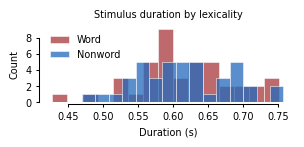

Coverage OK: 84/84 tokens (42 Word + 42 Nonword)


In [3]:
coverage = pd.DataFrame({
    "token": feat.tokens,
    "lexicality": feat.lexicality,
    "duration_s": feat.duration_s,
    "n_phones": feat.n_phones,
    "phones": feat.phones_str,
    "wav_path": feat.wav_path,
})
print(coverage["lexicality"].value_counts())
display(coverage.head(8))

fig, ax = plt.subplots(figsize=(8 * cm, 4 * cm))
for lex in ["Word", "Nonword"]:
    sub = coverage.loc[coverage.lexicality == lex, "duration_s"]
    ax.hist(
        sub,
        bins=15,
        alpha=0.75,
        label=lex,
        color=LEX_COLORS[lex],
        edgecolor="white",
        linewidth=0.5,
    )
ax.set_xlabel("Duration (s)", **fontdict)
ax.set_ylabel("Count", **fontdict)
ax.set_title("Stimulus duration by lexicality", **fontdict)
ax.legend(frameon=False, fontsize=fontsize)
style_axes(ax)
plt.tight_layout()
plt.show()

assert feat.n_tokens == 84
assert coverage["lexicality"].eq("Word").sum() == 42
assert coverage["lexicality"].eq("Nonword").sum() == 42
print("Coverage OK: 84/84 tokens (42 Word + 42 Nonword)")

## 2. Acoustic trust

For each example token: waveform + **log-mel spectrogram** recomputed from wav (freq × time), plus the cached 16-band `mel_logmean` vector from H5.


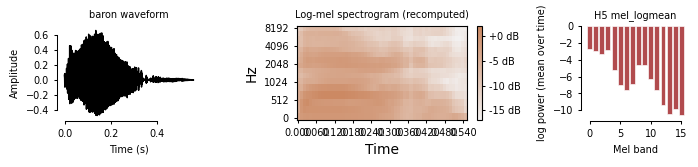

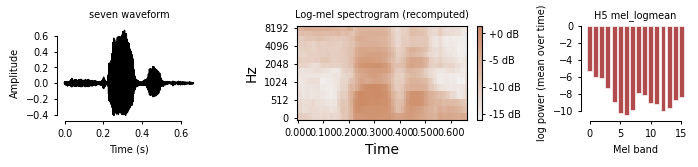

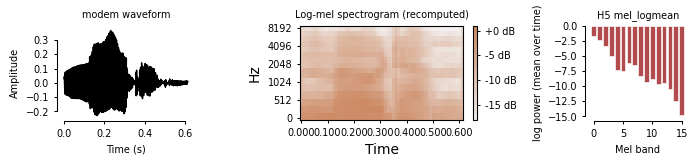

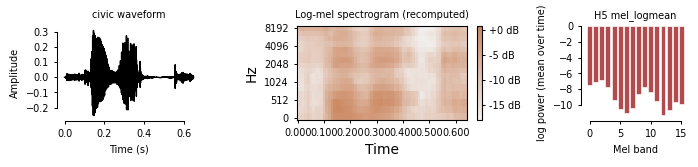

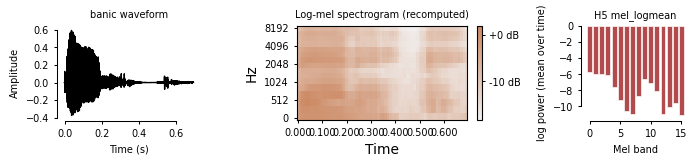

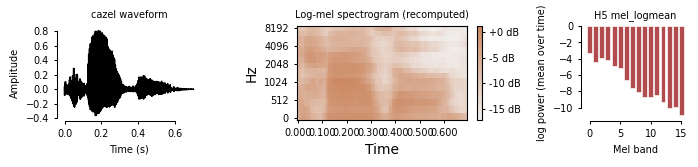

In [4]:
def compute_log_mel_spec(wav_path: str | Path) -> tuple[np.ndarray, np.ndarray, int, np.ndarray]:
    y, sr = librosa.load(str(wav_path), sr=SR_TARGET, mono=True)
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        hop_length=HOP_LENGTH,
        n_fft=N_FFT,
    )
    log_mel = np.log(mel + LOG_EPS)
    t = librosa.times_like(log_mel, sr=sr, hop_length=HOP_LENGTH)
    return y, log_mel, sr, t


def plot_acoustic_example(token: str) -> None:
    idx = feat.by_token(token)
    wav_path = feat.wav_path[idx]
    y, log_mel, sr, t = compute_log_mel_spec(wav_path)
    cached = feat.mel_logmean[idx]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18 * cm, 4.5 * cm),
        gridspec_kw={"width_ratios": [1.2, 1.6, 0.9]},
    )

    ax = axes[0]
    time = np.arange(len(y)) / sr
    ax.plot(time, y, color="k", lw=1)
    ax.set_title(f"{token} waveform", **fontdict)
    ax.set_xlabel("Time (s)", **fontdict)
    ax.set_ylabel("Amplitude", **fontdict)
    style_axes(ax)

    ax = axes[1]
    img = librosa.display.specshow(
        log_mel,
        x_axis="time",
        y_axis="mel",
        sr=sr,
        hop_length=HOP_LENGTH,
        fmin=FMIN,
        fmax=FMAX,
        ax=ax,
        cmap=oranges,
    )
    ax.set_title("Log-mel spectrogram (recomputed)", **fontdict)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2)
    cbar = fig.colorbar(img, ax=ax, format="%+2.0f dB", fraction=0.046)
    cbar.ax.tick_params(labelsize=fontsize, width=0.75, length=2)

    ax = axes[2]
    ax.bar(np.arange(N_MELS), cached, color=red, alpha=0.9, edgecolor="white", linewidth=0.5)
    ax.set_title("H5 mel_logmean", **fontdict)
    ax.set_xlabel("Mel band", **fontdict)
    ax.set_ylabel("log power (mean over time)", **fontdict)
    style_axes(ax)

    plt.tight_layout()
    plt.show()


for tok in EXAMPLE_TOKENS:
    plot_acoustic_example(tok)

## 3. Phonology trust

Position × phone one-hot matrices for example tokens. Compare `civic` vs `civil` (shared early structure, different vowels).


,token,lexicality,phones,n_phones
0,baron,Word,B AE R AH N,5
1,seven,Word,S EH V AH N,5
2,modem,Word,M OW D AH M,5
3,civic,Word,S IH V IH K,5
4,banic,Nonword,B AE N IH K,5
5,cazel,Nonword,K EY Z AH L,5
6,civil,Word,S IH V AH L,5


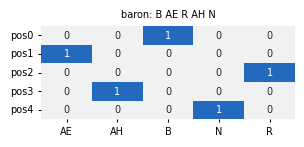

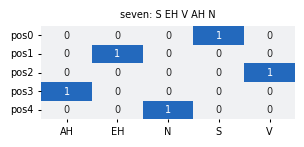

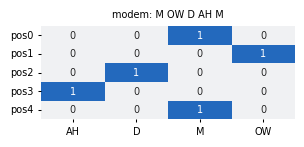

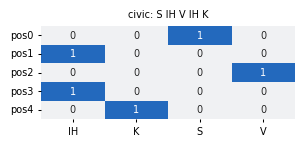

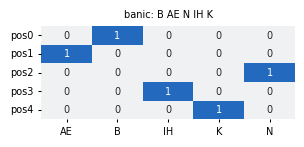

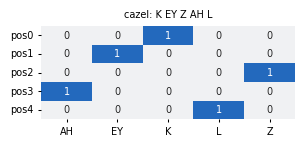

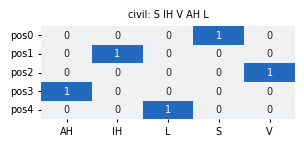

In [5]:
phon_examples = EXAMPLE_TOKENS + ["civil"]
rows = []
for tok in phon_examples:
    idx = feat.by_token(tok)
    rows.append({
        "token": tok,
        "lexicality": feat.lexicality[idx],
        "phones": feat.phones_str[idx],
        "n_phones": int(feat.n_phones[idx]),
    })
display(pd.DataFrame(rows))

phone_types = list(feat.phone_types)
n_pos = int(feat.attrs["n_pos"])


def plot_pos_phone(token: str) -> None:
    idx = feat.by_token(token)
    mat = feat.pos_phone[idx]
    active = mat.sum(axis=0) > 0
    cols = [p for p, on in zip(phone_types, active) if on]
    sub = mat[:, active]

    fig_w = max(8 * cm, 0.45 * cm * len(cols))
    fig, ax = plt.subplots(figsize=(fig_w, 4 * cm))
    sns.heatmap(
        sub,
        annot=True,
        fmt="d",
        cmap=blues,
        cbar=False,
        xticklabels=cols,
        yticklabels=[f"pos{i}" for i in range(n_pos)],
        annot_kws={"fontsize": fontsize},
        ax=ax,
    )
    ax.set_title(f"{token}: {feat.phones_str[idx]}", **fontdict)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2)
    plt.tight_layout()
    plt.show()


for tok in phon_examples:
    plot_pos_phone(tok)

## 4. Geometry sanity (Word-only, n=42)

Pairwise distance heatmaps and MDS for acoustic vs phonological features; Spearman correlation between RDMs.


Spearman(mel RDM, phon RDM) = 0.135 (p=7.49e-05)


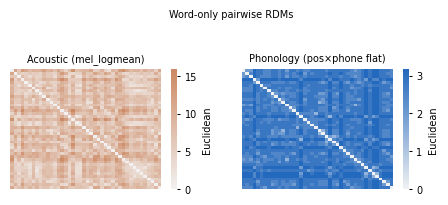

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


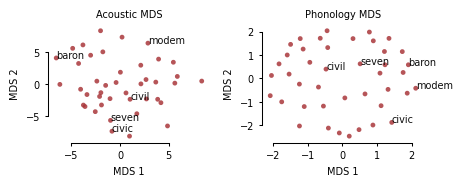

In [6]:
words = feat.subset_words()
word_tokens = list(words.tokens)

mel_rdm = squareform(pdist(words.mel_logmean, metric="euclidean"))
phon_rdm = squareform(pdist(words.pos_phone_flat.astype(float), metric="euclidean"))

triu = np.triu_indices(len(word_tokens), k=1)
rho, pval = spearmanr(mel_rdm[triu], phon_rdm[triu])
print(f"Spearman(mel RDM, phon RDM) = {rho:.3f} (p={pval:.3g})")

fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 5 * cm))
for ax, rdm, title, cmap in zip(
    axes,
    [mel_rdm, phon_rdm],
    ["Acoustic (mel_logmean)", "Phonology (pos×phone flat)"],
    [oranges, blues],
):
    sns.heatmap(
        rdm,
        xticklabels=False,
        yticklabels=False,
        cmap=cmap,
        ax=ax,
        cbar_kws={"label": "Euclidean"},
    )
    ax.set_title(title, **fontdict)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=fontsize, width=0.75, length=2)
    cbar.set_label("Euclidean", fontsize=fontsize)
fig.suptitle("Word-only pairwise RDMs", fontsize=fontsize, y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 5 * cm))
label_tokens = {"civic", "civil", "modem", "seven", "baron"}
for ax, X, title in zip(
    axes,
    [words.mel_logmean, words.pos_phone_flat.astype(float)],
    ["Acoustic MDS", "Phonology MDS"],
):
    coords = MDS(n_components=2, dissimilarity="euclidean", random_state=0).fit_transform(X)
    ax.scatter(coords[:, 0], coords[:, 1], s=12, alpha=0.85, color=red, edgecolors="none")
    for i, tok in enumerate(word_tokens):
        if tok in label_tokens:
            ax.annotate(tok, (coords[i, 0], coords[i, 1]), fontsize=fontsize, alpha=0.95)
    ax.set_title(title, **fontdict)
    ax.set_xlabel("MDS 1", **fontdict)
    ax.set_ylabel("MDS 2", **fontdict)
    style_axes(ax)
plt.tight_layout()
plt.show()